## Feature Matching

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Method - Display Images
def display(image):
    plt.figure(figsize=(12,10)).add_subplot(111)
    plt.imshow(image, cmap= 'gray')
    plt.show()

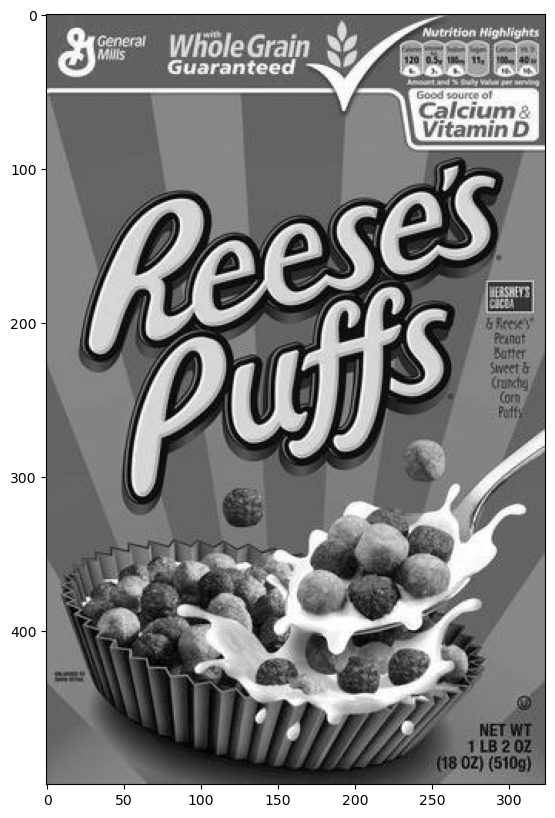

In [3]:
reeses  = cv2.imread('../dataset/img/reeses_puff.jpg',0)
display(reeses)

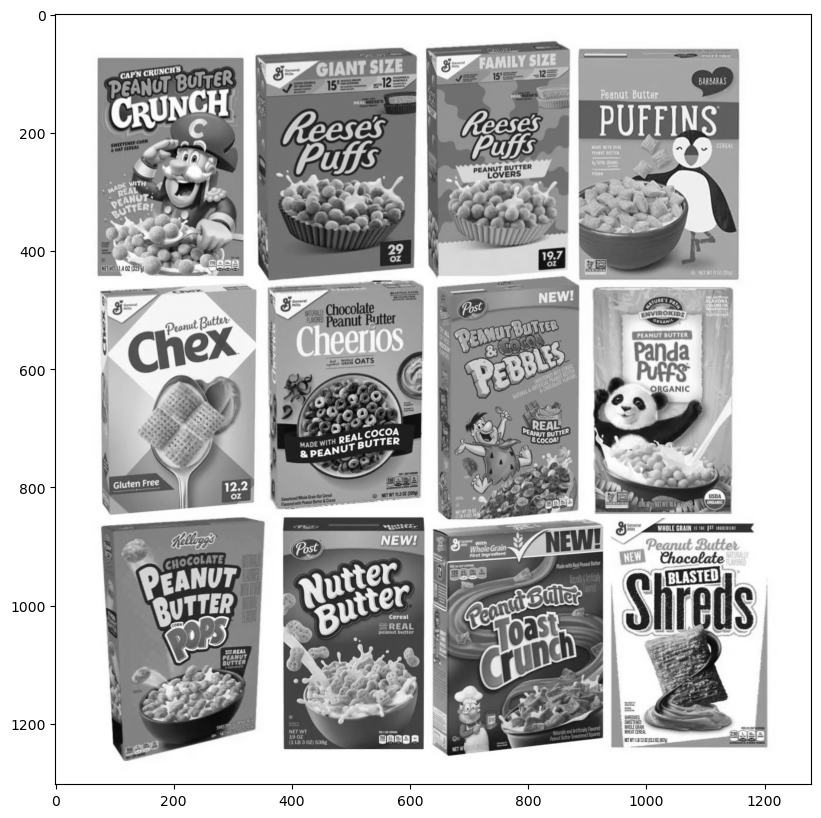

In [4]:
cereals = cv2.imread('../dataset/img/many_cereals.jpg',0)
display(cereals)

### Brute Force Detector with ORB Descriptor

In [8]:
# create ORB Object
orb = cv2.ORB_create()

# Extracting key points using orb's method detectAndCompute 
# we need to pass what image we want to detect and find Key features as well. 
# Second param is mask image if need otherwsie None.
keypoints1 , descriptors1 = orb.detectAndCompute(reeses, None)
keypoints2 , descriptors2 = orb.detectAndCompute(cereals, None)

# Brute force Matcher - NORM_HAMMING is default params
brute_force = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

# Now we can check where the matches occurs in both images
matches = brute_force.match(descriptors1, descriptors2)

# matches variable conatins bunch of specialized match objects.
# Each match object conatins a attribute named distance which clarifies how good the match was. 
#   Less Distance - Better Match
#   More Distance - Wrost Match

# Distance Calculation - Sort the matches with respect to their distance 
# Standard way to use Distance Calculation is using lambda expression along with sort method
matches = sorted(matches, key = lambda x:x.distance)
len(matches) # After filtering we have 162 matches

162

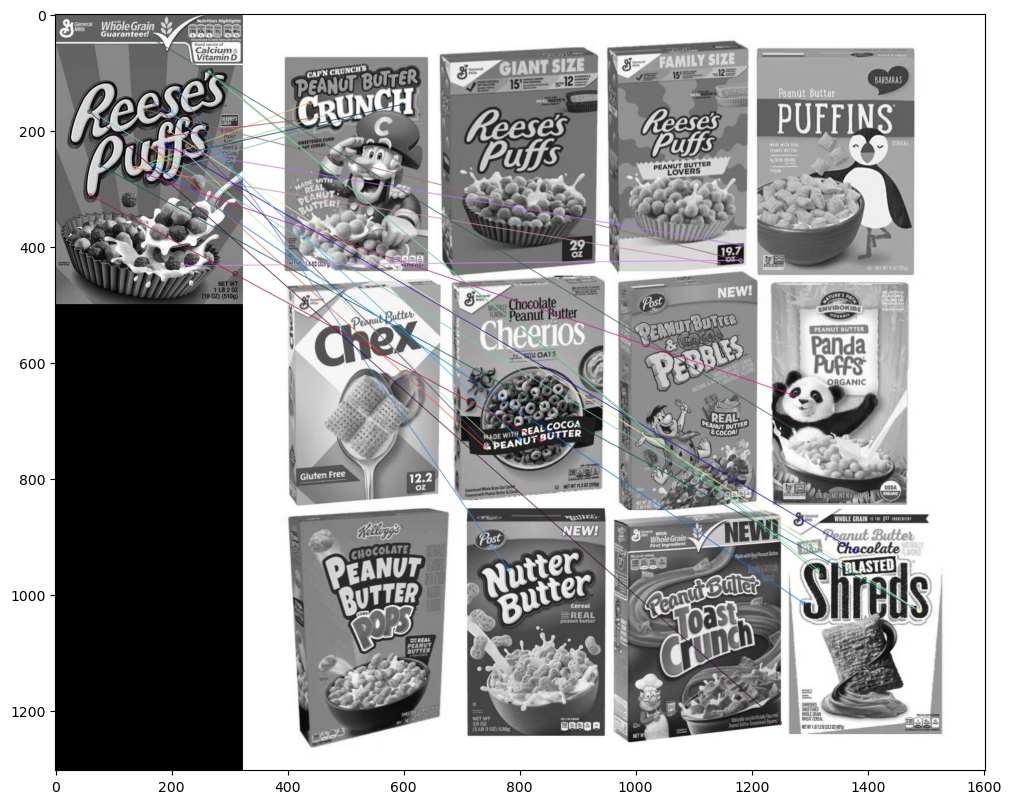

In [9]:
# Displaying matches

# we can display all the matches but for better visualization 
# we are taking first 25 matchs and displaying it for better understanding
reeses_matches = cv2.drawMatches(reeses, keypoints1, cereals, keypoints2, matches[:25], None, flags=2)

# It is not good at matching because the way 
# the images size are greatly varied and the letter/image positions are not same.
# It is useful when the almost same feature precent in the other image otherwise it preforms low.
display(reeses_matches)

### Brute force with SIFT Descriptor

In [15]:
# Create SIFT Object
sift = cv2.xfeatures2d.SIFT_create()

# Extracting key points using sift's method detectAndCompute 
keypoints1, descriptors1 = sift.detectAndCompute(reeses, None)
keypoints2, descriptors2 = sift.detectAndCompute(cereals, None)

# Brute force Matcher
brute_force = cv2.BFMatcher()

# Now matching the images with knnMatch 
# pass descriptors and 3 param - to define how many perfect match objects we want in the bunch of matches.
matches = brute_force.knnMatch(descriptors1, descriptors2, k=2)

# matches variable conatins bunch of specialized match objects in pairs.
# Here K=2, then 2 pairs of matching objects in a list.
# 1st Match is better than the second match

# Apply Ratio Test to filter these matches
# If the first match object's distance is closer to second object's distance attribute then it is a good feature match.
# Otherwise it is not a good match.

# Ratio Test Implementation
good_matches = []

# Less distance == Better Match
# Greater distance == wrost match
for m1, m2 in matches:
    # GOOD MATCH -->  Match 1 distance is less than 75% of Match 2 distance
    if m1.distance < 0.75 * m2.distance:
        good_matches.append([m1,m2])

print("Total Matches : ",(len(matches)))
print("Good Matches : ",(len(good_matches)))

Total Matches :  1187
Good Matches :  44


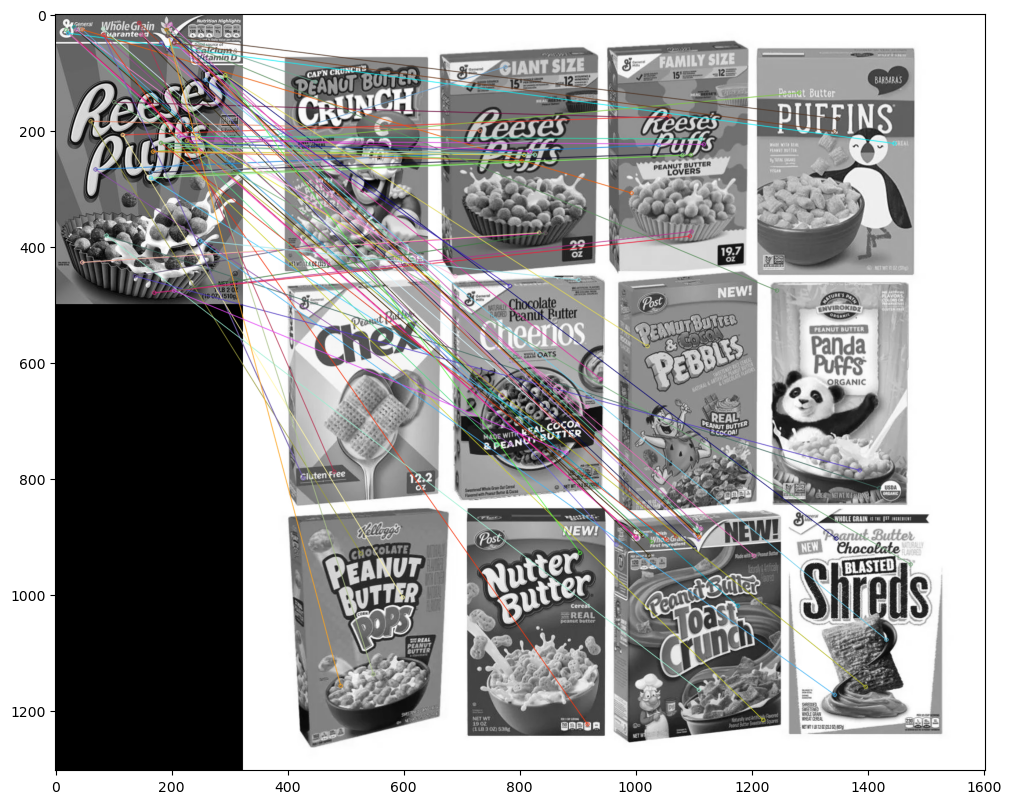

In [16]:
# draw these matches
reeses_matches = cv2.drawMatchesKnn(reeses, keypoints1, cereals, keypoints2, good_matches, None, flags=2)
display(reeses_matches)

### FLANN Based Matches

In [34]:
sift = cv2.xfeatures2d.SIFT_create()

# Extracting key points using sift's method detectAndCompute 
keypoints1, descriptors1 = sift.detectAndCompute(reeses, None)
keypoints2, descriptors2 = sift.detectAndCompute(cereals, None)

# FLANN Parameters - If the number are high then it might slower the performance
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm= FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)

# FLANN Matcher
flann = cv2.FlannBasedMatcher(index_params, search_params)

# Matching the descriptors using KnnMatch
matches = flann.knnMatch(descriptors1, descriptors2, k = 2)

# Creating Mask to show better understanding through visualization 
# by drawing the matching lines in specific color and shows all the matchs dot by setting flags = 0 in drawMatchesKnn method

# create a bunch of zeros as same size as matches
matchesMask = [[0,0] for i in range(len(matches))]

# Apply Ratio test --> Less Distance than setting the matchers Mask with [1,0] 
for i, (m1, m2) in enumerate(matches):
    # M1.distance is less than 75% of M2.distance = [0,1]
    if m1.distance < 0.75 * m2.distance:
        matchesMask[i] = [1,0]

# Setting colors for the matchs like single point match in grren and line matchs are in red
draw_params = dict(matchColor= (255,0,0), singlePointColor=(0, 255, 0), matchesMask = matchesMask, flags = 0)

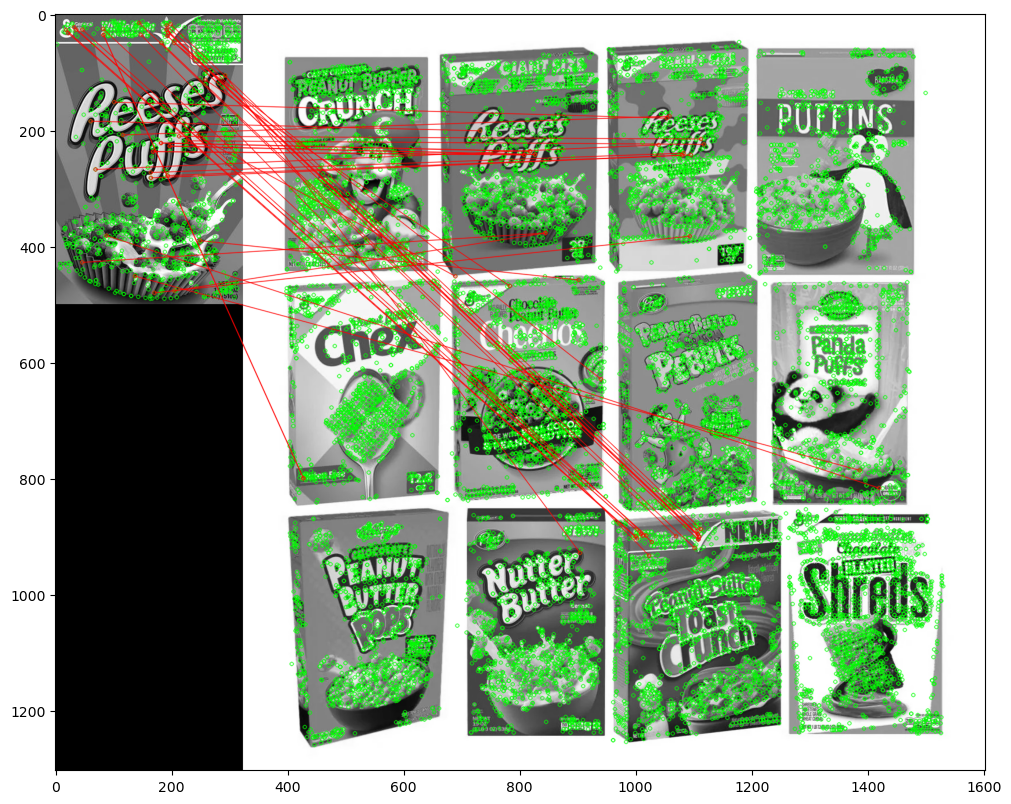

In [33]:
# draw the matches and displays it
reeses_matches = cv2.drawMatchesKnn(reeses, keypoints1, cereals, keypoints2, matches, None, **draw_params)
display(reeses_matches)